# Exercises XP: Deep Learning, ANNs and Polynomial Overfitting

Week 10, Day 4

**What you will learn**
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.

## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| **Feature Engineering** | Done manually: experts design the input features (ratios, aggregates, edge histograms...). Model quality depends heavily on these features. | Largely automatic: the network learns its own features from raw data through its successive layers (representation learning). |
| **Data Processing** | Works best on structured, tabular data (rows and columns) that has been cleaned, encoded and often scaled. | Can process raw, unstructured data directly: images, audio, text, video, as tensors of pixels, samples or tokens. |
| **Scalability** | Performance improves with more data, then plateaus quickly; works well on small to medium datasets (hundreds to thousands of rows). | Performance keeps improving with more data and larger models; needs large datasets (often millions of examples) to shine and to avoid overfitting. |
| **Pattern Discovery** | Captures the relationships allowed by the chosen model and features (linear boundaries, tree splits); more interpretable. | Discovers complex, non-linear and hierarchical patterns (edges → shapes → objects) that are hard to define by hand; less interpretable ("black box"). |
| **Computational Requirements** | Low: trains in seconds or minutes on a regular CPU. | High: training needs GPUs/TPUs, a lot of memory and can take hours to weeks. |

**Real-world examples:**

- **Traditional ML is better suited for credit scoring / loan default prediction.** The data is tabular (income, age, debt ratio, payment history), datasets are usually moderate in size, and banks must be able to explain each decision to customers and regulators. A logistic regression or gradient boosting model is accurate, fast and interpretable here.
- **Deep learning is better suited for medical image analysis** (e.g. detecting tumours on X-rays or MRI scans). The input is raw pixels, the relevant patterns (shapes, textures) are too complex to describe by hand, and large labelled image datasets exist. Convolutional neural networks reach expert-level accuracy on such tasks.

**Why deep learning has an advantage on unstructured data:**

Unstructured data such as images, sound or text has no ready-made columns: the useful information is hidden in the relations between thousands of raw values (pixels, audio samples, words). Deep learning relies on **representation learning**: instead of receiving hand-crafted features, the network learns them directly from the raw data by adjusting its weights. Its stacked layers build **hierarchical features**: in an image, the first layers detect edges and colours, the middle layers combine them into textures and parts, and the deepest layers recognise whole objects. Specialised architectures exploit the structure of the data (convolutions for spatial patterns, recurrent networks and transformers for sequences), so the same approach scales to very large datasets where manual feature engineering would be impossible.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

Network with an input layer of 3 neurons, one hidden layer of 4 neurons and an output layer of 2 neurons.

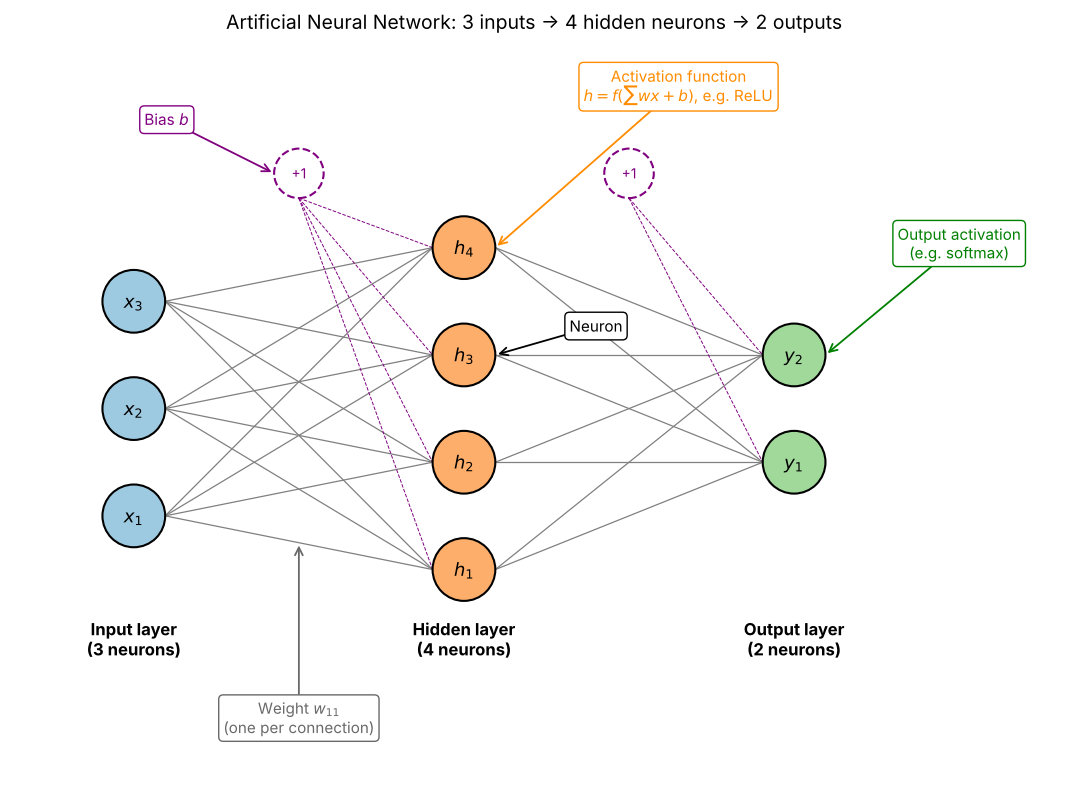

Weights: 20 (3×4 + 4×2) | Biases: 6 (4 + 2) | Trainable parameters: 26


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

layer_sizes = [3, 4, 2]
layer_x = [0, 4, 8]
layer_names = ['Input layer\n(3 neurons)', 'Hidden layer\n(4 neurons)', 'Output layer\n(2 neurons)']
colors = ['#9ecae1', '#fdae6b', '#a1d99b']
r = 0.38

def neuron_y(n):
    return np.linspace(-(n - 1) * 0.65, (n - 1) * 0.65, n)

fig, ax = plt.subplots(figsize=(13, 8))
positions = [[(x, y) for y in neuron_y(n)] for x, n in zip(layer_x, layer_sizes)]

# Connections = weights
for l in range(len(positions) - 1):
    for (x1, y1) in positions[l]:
        for (x2, y2) in positions[l + 1]:
            ax.plot([x1 + r, x2 - r], [y1, y2], color='gray', lw=0.9, zorder=1)

# Neurons
for l, layer in enumerate(positions):
    for i, (x, y) in enumerate(layer):
        ax.add_patch(Circle((x, y), r, facecolor=colors[l], edgecolor='black', lw=1.5, zorder=3))
        label = [f'$x_{i+1}$', f'$h_{i+1}$', f'$y_{i+1}$'][l]
        ax.text(x, y, label, ha='center', va='center', fontsize=13, zorder=4)
    ax.text(layer_x[l], -2.55, layer_names[l], ha='center', va='top', fontsize=12, fontweight='bold')

# Bias units feeding the hidden and output layers
for l, bx in [(1, 2.0), (2, 6.0)]:
    by = 2.85
    ax.add_patch(Circle((bx, by), 0.3, facecolor='white', edgecolor='purple', lw=1.5, ls='--', zorder=3))
    ax.text(bx, by, '+1', ha='center', va='center', fontsize=10, color='purple', zorder=4)
    for (x2, y2) in positions[l]:
        ax.plot([bx, x2 - r], [by - 0.3, y2], color='purple', lw=0.7, ls='--', zorder=1)

# Annotations: each requested label appears once
def note(text, xy, xytext, color='black'):
    ax.add_patch(FancyArrowPatch(xytext, xy, arrowstyle='->', mutation_scale=14, color=color, lw=1.3, zorder=5))
    ax.text(*xytext, text, fontsize=11, color=color, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color), zorder=6)

x1, y1 = positions[0][0]
x2, y2 = positions[1][0]
note('Weight $w_{11}$\n(one per connection)', ((x1 + x2) / 2, (y1 + y2) / 2), (2.0, -3.75), color='dimgray')
note('Neuron', (positions[1][2][0] + r, positions[1][2][1]), (5.6, 1.0), color='black')
note('Bias $b$', (1.7, 2.85), (0.4, 3.5), color='purple')
note('Activation function\n$h = f(\\sum w x + b)$, e.g. ReLU', (positions[1][3][0] + r, positions[1][3][1]), (6.6, 3.9), color='darkorange')
note('Output activation\n(e.g. softmax)', (positions[2][1][0] + r, positions[2][1][1]), (10.0, 2.0), color='green')

ax.set_xlim(-1.5, 11.2)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Artificial Neural Network: 3 inputs → 4 hidden neurons → 2 outputs', fontsize=14)
plt.tight_layout()
plt.show()

n_weights = 3 * 4 + 4 * 2
n_biases = 4 + 2
print(f"Weights: {n_weights} (3×4 + 4×2) | Biases: {n_biases} (4 + 2) | Trainable parameters: {n_weights + n_biases}")

**Labelled components:**
- **Neurons** (circles): x₁–x₃ in the input layer, h₁–h₄ in the hidden layer, y₁–y₂ in the output layer.
- **Weights** (grey lines): one weight per connection, 3×4 + 4×2 = 20 weights in total.
- **Biases** (purple "+1" units): one bias per hidden and output neuron, 6 biases in total.
- **Activation function**: applied inside each hidden neuron (e.g. ReLU) and at the output (e.g. softmax for 2 classes).
- **Layers**: input layer, hidden layer, output layer.

**How information flows through the network (forward propagation):**
The three **inputs** x₁, x₂, x₃ enter the input layer, which just passes them on. Each hidden neuron computes a **weighted sum** of all the inputs, z = w₁x₁ + w₂x₂ + w₃x₃, and adds its **bias** b to it. It then applies an **activation function** (e.g. ReLU, h = max(0, z)), which introduces non-linearity. The four hidden activations become the inputs of the output layer, where the same operation (weighted sum + bias + activation, here softmax) produces the two **outputs** y₁ and y₂, for example the probabilities of two classes. During training, the error on these outputs is propagated backwards to adjust the weights and biases.

**Learning point**
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.

## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

Create 20 points from $y = -x^2$ with Gaussian noise $\mathcal{N}(0, 0.05)$, plot them, and split into a training set (first 12 points) and a test set (last 8 points).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [3]:
y = -x**2 + np.random.normal(0, 0.05, len(x))
print("y shape:", y.shape)

y shape: (20,)


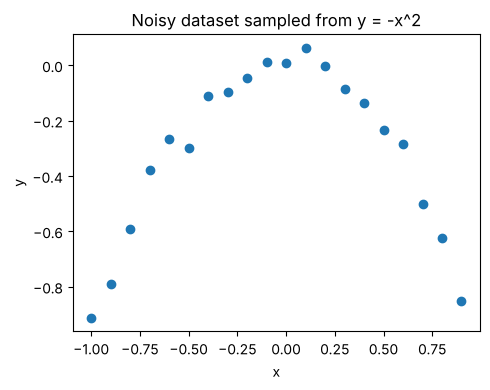

In [4]:
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

train sizes: (12,) (12,) test sizes: (8,) (8,)
train x range: [-1.0, 0.1] | test x range: [0.2, 0.9]


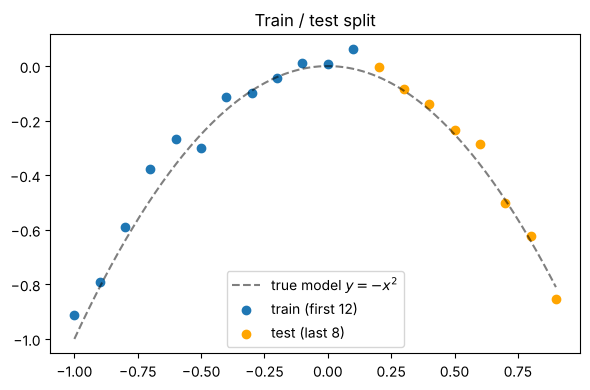

In [5]:
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)
print(f"train x range: [{x_train.min():.1f}, {x_train.max():.1f}] | test x range: [{x_test.min():.1f}, {x_test.max():.1f}]")

x_dense = np.linspace(-1, 0.9, 200)
plt.figure(figsize=(6, 4))
plt.plot(x_dense, -x_dense**2, 'k--', alpha=0.5, label='true model $y=-x^2$')
plt.scatter(x_train, y_train, label='train (first 12)')
plt.scatter(x_test, y_test, color='orange', label='test (last 8)')
plt.legend()
plt.title('Train / test split')
plt.tight_layout()
plt.show()

The points follow the parabola y = −x² with small random deviations. Because the split is done by position, the training set covers x ∈ [−1, 0.1] and the test set covers x ∈ [0.2, 0.9]: the test is an **extrapolation** to a region the model has never seen, which makes overfitting very visible.

**Learning point**
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.

## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

In [6]:
def polynomial_fit(degree: int):
    """Fit a polynomial of the given degree on the training data and return it as a callable."""
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def plot_polyfit(degree: int, ax=None):
    # 1) fit
    p = polynomial_fit(degree)
    # 2) create a dense linspace over x range
    x_dense = np.linspace(x.min(), x.max(), 300)
    # 3) evaluate fitted polynomial
    y_dense = p(x_dense)
    # 4) scatter train and test, and plot curve
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(x_train, y_train, label='train')
    ax.scatter(x_test, y_test, color='orange', label='test')
    ax.plot(x_dense, y_dense, 'r-', label=f'degree {degree} fit')
    ax.plot(x_dense, -x_dense**2, 'k--', alpha=0.4, label='true $y=-x^2$')
    ax.set_ylim(-2, 1)
    ax.set_title(f'Degree {degree}: train RMSE = {rmse(y_train, p(x_train)):.3g}, test RMSE = {rmse(y_test, p(x_test)):.3g}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='lower left')
    # 5) display
    return ax

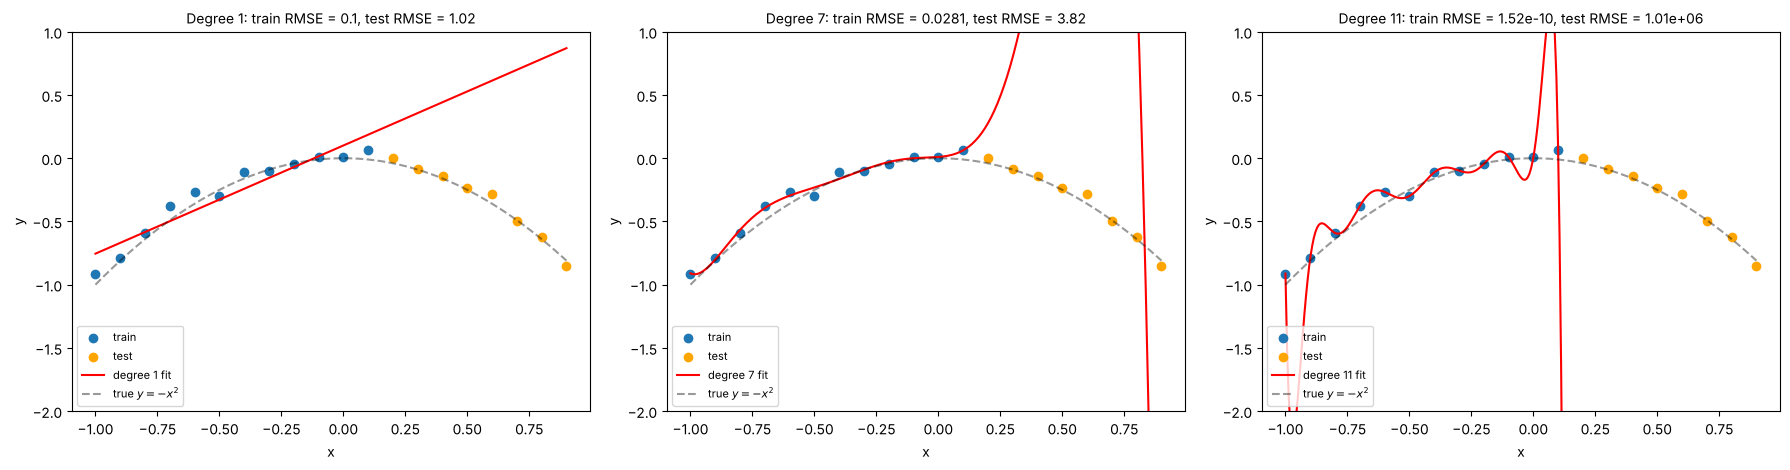

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
plot_polyfit(1, axes[0])
plot_polyfit(7, axes[1])
plot_polyfit(11, axes[2])
plt.tight_layout()
plt.show()

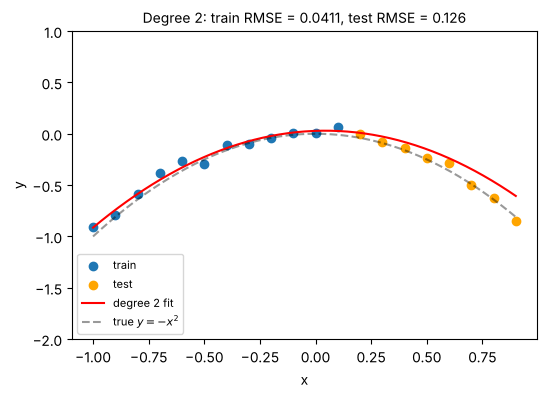

Degree 2 coefficients (a x^2 + b x + c): [-0.867  0.075  0.028]


In [9]:
# Bonus: the true degree for comparison
plot_polyfit(2)
plt.show()
print("Degree 2 coefficients (a x^2 + b x + c):", polynomial_fit(2).coeffs.round(3))

**Observations:**
- **Degree 1** (a straight line) is too simple: it cannot follow the curvature of the parabola. Its training error is the highest (RMSE ≈ 0.10) and it misses the test points badly (≈ 1.02). This is **underfitting** (high bias).
- **Degree 7** fits the training points more closely (train RMSE ≈ 0.028), but between and beyond them it wiggles to follow the noise. In the test region it goes far away from the parabola (test RMSE ≈ 3.8).
- **Degree 11** has 12 coefficients for 12 training points, so it passes **exactly through every training point** (train RMSE ≈ 0). It has memorised the noise, and in the test region it explodes (test RMSE ≈ 10⁶). This is extreme **overfitting** (high variance).
- **Degree 2**, the true degree, follows the parabola everywhere and has the lowest test error (≈ 0.13); its coefficients are close to the true model (≈ −0.87x² + 0.08x + 0.03 vs −x²).

As the degree increases, the training error always decreases, but the test error does not: a low training error is not a proof of a good model.

**Learning point**
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)
for d in degrees:
    # fit on train
    p = polynomial_fit(d)
    # evaluate on train and test
    rows.append((d, rmse(y_train, p(x_train)), rmse(y_test, p(x_test))))
rows[:3]  # peek

[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556869)),
 (2, np.float64(0.04114590494650987), np.float64(0.12578064282386506)),
 (3, np.float64(0.03733692231108597), np.float64(0.7696519930800758))]

In [11]:
import pandas as pd
results = pd.DataFrame(rows, columns=['degree', 'RMSE train', 'RMSE test']).set_index('degree')
display(results.style.format('{:.4g}').highlight_min(subset=['RMSE test'], color='lightgreen'))

,RMSE train,RMSE test
degree,,
1,0.1002,1.024
2,0.04115,0.1258
3,0.03734,0.7697
4,0.03684,1.7
5,0.03494,6.207
6,0.02837,58.83
7,0.02813,3.819
8,0.02756,523.8
9,0.02087,1.017e+04


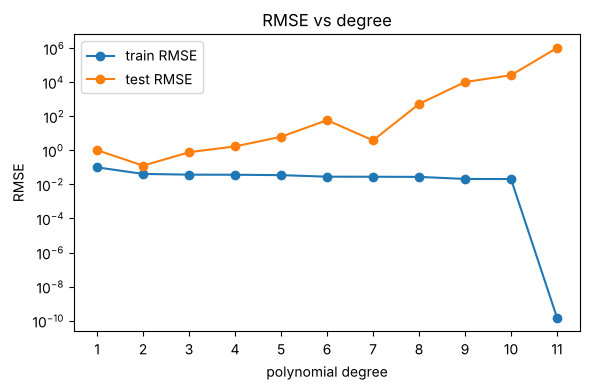

Degree with the minimum test RMSE: 2 (test RMSE = 0.1258)


In [12]:
# Plotting RMSE curves (one figure, two curves)
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, 'o-', label="train RMSE")
plt.plot(degs, rmse_te, 'o-', label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.xticks(degs)
plt.legend()
plt.tight_layout()
plt.show()

best_degree, _, best_test = min(rows, key=lambda r: r[2])
print(f"Degree with the minimum test RMSE: {best_degree} (test RMSE = {best_test:.4f})")

In [13]:
# Bonus: k-fold cross-validation on all 20 points (random folds, interpolation instead of extrapolation)
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_rows = []
for d in degrees:
    fold_rmse = []
    for tr, te in kf.split(x):
        p = np.poly1d(np.polyfit(x[tr], y[tr], d))
        fold_rmse.append(rmse(y[te], p(x[te])))
    cv_rows.append((d, np.mean(fold_rmse)))
cv_df = pd.DataFrame(cv_rows, columns=['degree', 'mean CV RMSE']).set_index('degree')
display(cv_df.style.format('{:.4g}').highlight_min(color='lightgreen'))
print("Best degree with 5-fold CV:", cv_df['mean CV RMSE'].idxmin())

,mean CV RMSE
degree,
1,0.3332
2,0.0462
3,0.04256
4,0.04705
5,0.04843
6,0.07112
7,0.2327
8,0.198
9,0.7594


Best degree with 5-fold CV: 3


**Result:** the degree with the minimum test RMSE is **degree 2** (test RMSE ≈ 0.126). This matches the true underlying model y = −x², which is a polynomial of degree 2.

- **Degree 1** is too simple (high **bias**): both training and test errors are high.
- From **degree 3 onwards**, the training RMSE keeps decreasing (down to ≈ 10⁻¹⁰ for degree 11, which interpolates the 12 training points), but the test RMSE grows dramatically, up to ≈ 10⁶ for degree 11. The extra coefficients fit the noise of the training points (high **variance**), and they make the curve shoot off in the test region.

This is the **bias–variance trade-off**: the best model is the one complex enough to capture the true signal, but no more. Degree 2 is exactly this sweet spot.

**Bonus - k-fold cross-validation:** with random folds on all 20 points, every test point lies *between* training points (interpolation instead of extrapolation), so the errors are much smaller for all degrees. Degrees 2 and 3 are then practically tied (mean CV RMSE ≈ 0.046 vs 0.043), and the small advantage of degree 3 is within the noise of a 20-point dataset. The large errors of degrees 1 and ≥ 5 are still clearly visible. With so few points, choosing the simplest model among those with a similar error (degree 2) is the safest choice, and it is the one that generalises best to new x values, as the extrapolation test above shows.